In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

from IPython.display import display

In [3]:
df = pd.read_csv("/content/unidraw_users_ab-5a33216c-c8f8-4e25-8355-00c881b72410.csv")
users = pd.read_csv("/content/unidraw_users-93957134-e8c5-4499-a9c6-35457b2f6e94 (1).csv")
visits = pd.read_csv('/content/visits_clean2.csv')
templates = pd.read_csv('/content/unidraw_templates-48225651-72ae-4f06-a029-ec918481771f (1).csv')

visits.head()

,user_id,event_id,event_dttm,board_id,city_nm,device_type_code
0,5b3c2b1b17f1b55,5afbb8efb02b5f1,2026-04-08 10:42:59.022,04724236f129849,Нижневартовск,HIGHEND_PHONE
1,e1b1e4f8ca2e638,20bba875de930ba,2026-04-08 09:20:12.470,27394abfecbdf41,Москва,PERSONAL_COMPUTER
2,14040e52b3e09d5,21f8ae5ff84280c,2026-04-08 09:52:19.958,c4bf0672664c0dd,Москва,PERSONAL_COMPUTER
3,1e280e597acc466,f0d5d72b506415d,2026-04-08 09:30:40.170,988f58e9d800171,Москва,PERSONAL_COMPUTER
4,73efda4928c0a06,64bb1b0543053c1,2026-04-08 09:24:58.661,cc3607efc7d13db,Санкт-Петербург,PERSONAL_COMPUTER


**1. Первичная проверка данных**

In [4]:
# Смотрим количество пользователей в каждой группе
print("Размеры групп:")
print(df["group_name"].value_counts())


# Проверяем дубликаты пользователей
print("\nКоличество дубликатов user_id:")
print(df["user_id"].duplicated().sum())


# Проверяем пропуски
print("\nКоличество пропусков по столбцам:")
print(df.isna().sum())


# Проверяем, какие значения есть в группах
print("\nЗначения group_name:")
print(df["group_name"].unique())


# Проверяем значения сферы деятельности
print("\nКоличество уникальных сфер деятельности:")
print(df["industry"].nunique())

print("\nЗначения industry:")
print(df["industry"].unique())


# Проверяем отрицательные значения template_activity
print("\nКоличество отрицательных значений template_activity:")
print((df["template_activity"] < 0).sum())


# Проверяем нулевые значения template_activity
print("\nКоличество нулевых значений template_activity:")
print((df["template_activity"] == 0).sum())


# Проверяем бесконечные значения
print("\nКоличество бесконечных значений template_activity:")
print(np.isinf(df["template_activity"]).sum())


# Проверяем основные статистики метрики
print("\nОписательная статистика template_activity:")
print(df["template_activity"].describe())


# Общая информация о таблице
print("\nИнформация о датафрейме:")
df.info()


# Первые пять строк
df.head()

Размеры групп:
group_name
control    12810
test       12732
Name: count, dtype: int64

Количество дубликатов user_id:
0

Количество пропусков по столбцам:
user_id                  0
group_name               0
industry             16574
template_activity        0
dtype: int64

Значения group_name:
['control' 'test']

Количество уникальных сфер деятельности:
12

Значения industry:
['Преподавание и обучение' nan 'Другое' 'Разработка и инженерия'
 'Аналитика и исследования' 'Маркетинг и реклама' 'Дизайн'
 'Управление продуктом' 'Управление командой' 'Редактура и копирайтинг'
 'Бизнес и предпринимательство' 'Финансы и консалтинг'
 'Поддержка и сервис']

Количество отрицательных значений template_activity:
0

Количество нулевых значений template_activity:
0

Количество бесконечных значений template_activity:
0

Описательная статистика template_activity:
count    25542.000000
mean         5.124618
std          1.156737
min          0.457200
25%          4.344350
50%          5.124650
75%     

,user_id,group_name,industry,template_activity
0,2fc14f889d52a89,control,Преподавание и обучение,5.0771
1,c118a6226618b3f,control,NaN,4.2615
2,3ef46bf37f0e3be,test,Другое,5.3991
3,d7ab835a0f1329a,control,NaN,4.2821
4,29f7e4f0ce4bc97,control,NaN,4.4862


In [5]:
users_in_multiple_groups = (
df.groupby("user_id")["group_name"]
    .nunique()
    .gt(1)
    .sum()
)

print("\nПользователей, попавших сразу в несколько групп:")
print(users_in_multiple_groups)


Пользователей, попавших сразу в несколько групп:
0


**2. Проверка однородности групп**

In [6]:
#объединяем таблицы
df = df.merge(users[
        [
            "user_id",
            "gender",
            "age_segment"
        ]
    ],
    on="user_id",
    how="left"
)

df.head()

,user_id,group_name,industry,template_activity,gender,age_segment
0,2fc14f889d52a89,control,Преподавание и обучение,5.0771,f,18-24 года
1,c118a6226618b3f,control,NaN,4.2615,f,18-24 года
2,3ef46bf37f0e3be,test,Другое,5.3991,f,18-24 года
3,d7ab835a0f1329a,control,NaN,4.2821,f,25-34 года
4,29f7e4f0ce4bc97,control,NaN,4.4862,f,младше 18 лет


In [7]:
#Проверка industry
#H0:распределение сфер деятельности в тестовой и контрольной группах одинаковое
#H1:распределение сфер деятельности различается
#категориальный признак => берем хи квадрат пирсона


alpha = 0.05

df["industry_for_test"] = df["industry"].fillna("Не указана")
industry_table = pd.crosstab(
    df["group_name"],
    df["industry_for_test"]
)

# Рассчитываем доли сфер деятельности внутри каждой группы
industry_shares = (
    pd.crosstab(
        df["group_name"],
        df["industry_for_test"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("Доли пользователей по сферам деятельности, %:")
display(industry_shares)

# Проводим критерий хи-квадрат
chi2_stat, p_value, dof, expected = chi2_contingency(
    industry_table
)

print(f"Статистика chi-square: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Доли пользователей по сферам деятельности, %:


industry_for_test,Аналитика и исследования,Бизнес и предпринимательство,Дизайн,Другое,Маркетинг и реклама,Не указана,Поддержка и сервис,Преподавание и обучение,Разработка и инженерия,Редактура и копирайтинг,Управление командой,Управление продуктом,Финансы и консалтинг
group_name,,,,,,,,,,,,,
control,0.73,0.84,1.50,3.98,0.38,64.75,0.15,23.58,1.76,0.37,1.13,0.66,0.19
test,0.69,0.84,1.37,3.93,0.44,65.03,0.19,23.44,1.76,0.27,1.04,0.68,0.31


Статистика chi-square: 8.4950
p-value: 0.7454


вывод:p-value больше 0.05, поэтому нет оснований отвергать нулевую гипотезу. Результат не стат. значим, данных недостаточно, чтобы обнаружить различие

In [8]:
#бинарный признак - берем z-тест долей
df_gender = df.copy()


# Проверяем пропуски и возможные значения
print("Значения gender:")
print(df_gender["gender"].value_counts(dropna=False))

alpha = 0.05
female_count = (
    df_gender["gender"]
    .eq("f")
    .groupby(df_gender["group_name"])
    .sum()
)
group_size = (
    df_gender
    .groupby("group_name")
    .size()
)
print("\nКоличество женщин по группам:")
print(female_count)

female_share = (female_count / group_size * 100).round(2)

print("\nОбщее количество пользователей по группам:")
print(group_size)

print("\nДоля женщин по группам, %:")
print(female_share)

z_stat, p_value = proportions_ztest(count=female_count.to_numpy(), nobs=group_size.to_numpy())

print(f"\nz-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Значения gender:
gender
f    12776
m    12766
Name: count, dtype: int64

Количество женщин по группам:
group_name
control    6407
test       6369
Name: gender, dtype: int64

Общее количество пользователей по группам:
group_name
control    12810
test       12732
dtype: int64

Доля женщин по группам, %:
group_name
control    50.02
test       50.02
dtype: float64

z-статистика: -0.0127
p-value: 0.9899


вывод: p-value = 0.98 > 0.05 => нет оснований отвергать гипотезу H0 об однородности групп по признаку gender. Статистически значимых различий по полу между тестовой и контрольной группами нету.

In [9]:
#так же категориальный - берем хи квадрат пирсона
alpha = 0.05
print("Распределение пользователей по возрастным сегментам:")
print(df["age_segment"].value_counts(dropna=False))
age_table = pd.crosstab(
    df["group_name"],
    df["age_segment"]
)

print("\nКоличество пользователей по возрастным сегментам:")
display(age_table)

# Считаем доли каждого из сегментов внутри каждой группы
age_share = (
    pd.crosstab(
        df["group_name"],
        df["age_segment"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("\nДоли возрастных сегментов внутри групп, %:")
display(age_share)

# Проводим критерий хи-квадрат
chi2_stat, p_value, dof, expected = chi2_contingency(age_table)
print(f"Статистика chi-square: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Распределение пользователей по возрастным сегментам:
age_segment
18-24 года         9378
25-34 года         7683
младше 18 лет      4411
35-44 года         2736
45-54 года         1018
55 лет и старше     316
Name: count, dtype: int64

Количество пользователей по возрастным сегментам:


age_segment,18-24 года,25-34 года,35-44 года,45-54 года,55 лет и старше,младше 18 лет
group_name,,,,,,
control,4693,3851,1375,515,164,2212
test,4685,3832,1361,503,152,2199



Доли возрастных сегментов внутри групп, %:


age_segment,18-24 года,25-34 года,35-44 года,45-54 года,55 лет и старше,младше 18 лет
group_name,,,,,,
control,36.64,30.06,10.73,4.02,1.28,17.27
test,36.80,30.10,10.69,3.95,1.19,17.27


Статистика chi-square: 0.5227
p-value: 0.9913


p-value = 0,99 > 0,05, поэтому результат статистически незначим и нет оснований отвергать нулевую гипотезу. Группы можно считать однородными по возрасту.

общий вывод для задания №3:  по результатам всех трех тестов значимых различий между тестовой и контрольной группами по сфере деятельности, полу и возрастному сегменту не обнаружено. Следовательно, группы можно считать однородными по рассматриваемым признакам.

**2.распределение template_activity**

In [10]:
template_info = (
    df.groupby("group_name")["template_activity"]
    .agg(
        users_count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(4)
)
print('Количество пропусков в метрике:')
res = df["template_activity"].isna().sum()
print(res)
template_info


Количество пропусков в метрике:
0


,users_count,mean,median,std,min,max
group_name,,,,,,
control,12810,5.00,5.00,1.15,0.4572,9.5428
test,12732,5.25,5.25,1.15,0.7089,9.7911


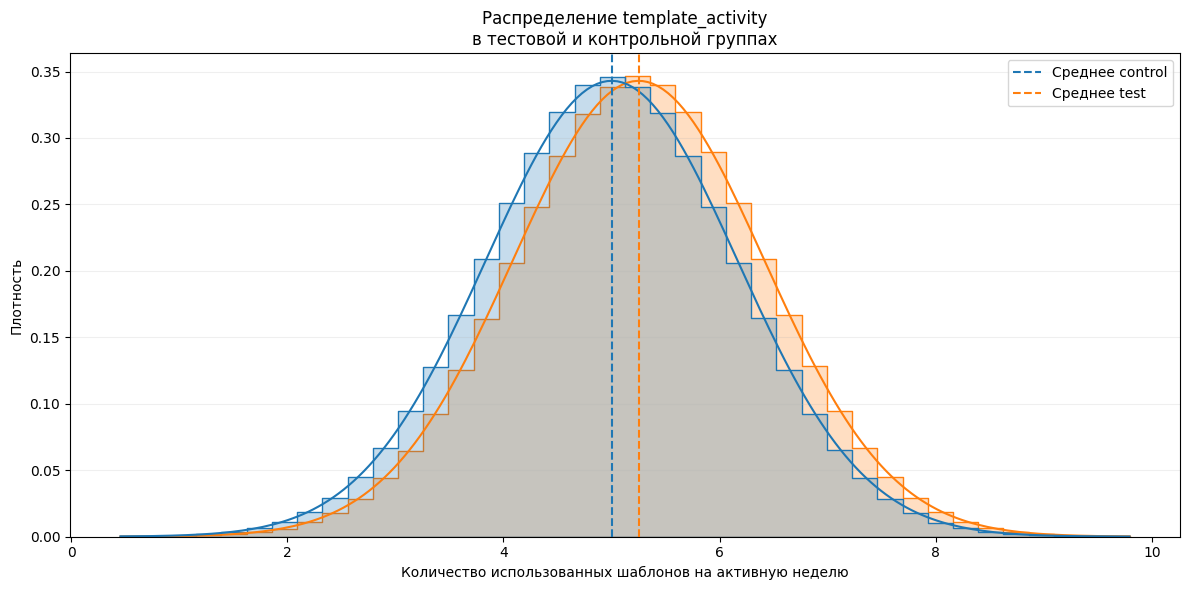

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="template_activity",
    hue="group_name",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    kde=True,
    alpha=0.25
)

plt.axvline(
    df.loc[
        df["group_name"] == "control",
        "template_activity"
    ].mean(),
    color="#1f77b4",
    linestyle="--",
    label="Среднее control"
)

plt.axvline(
    df.loc[
        df["group_name"] == "test",
        "template_activity"
    ].mean(),
    color="#ff7f0e",
    linestyle="--",
    label="Среднее test"
)

plt.title(
    "Распределение template_activity\n"
    "в тестовой и контрольной группах"
)
plt.xlabel("Количество использованных шаблонов на активную неделю")
plt.ylabel("Плотность")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

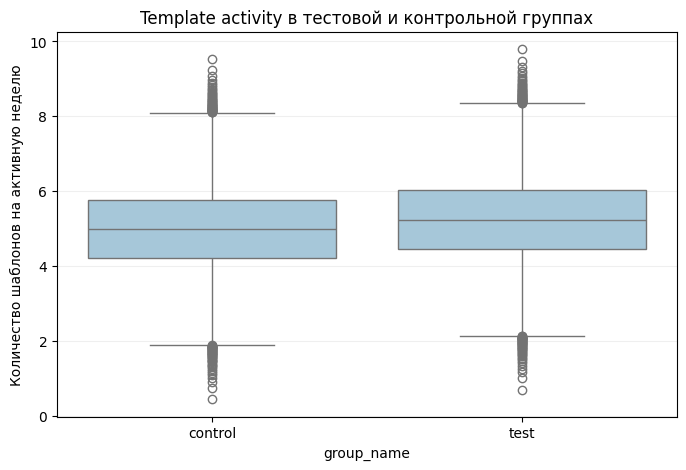

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="group_name",
    y="template_activity",
    order=["control", "test"],
    color="#9ECAE1"
)

plt.title("Template activity в тестовой и контрольной группах")
plt.ylabel("Количество шаблонов на активную неделю")
plt.grid(axis="y", alpha=0.2)
plt.show()

вывод по двум графикам о распределение метрики: распределения в группах имеют похожую симметричную форму и примерно одинаковое отклоение от средних. При этом распределение контрольной группы расположено левее, а распределение тестовой группы - правее. Это означает, что значения template_activity в тестовой группе в среднем выше: 5,25 против 5,00 в контрольной, что говорит о тестовая группа более активная.

In [13]:
from scipy.stats import shapiro

alpha = 0.05

control = df.loc[
    df["group_name"] == "control",
    "template_activity"
]

test = df.loc[
    df["group_name"] == "test",
    "template_activity"
]

# Берём по 5000 случайных наблюдений
control_sample = control.sample(
    n=5000,
    random_state=42
)

test_sample = test.sample(
    n=5000,
    random_state=42
)
control_stat, control_p = shapiro(control_sample)
test_stat, test_p = shapiro(test_sample)

print("Контрольная группа:")
print(f"Статистика Шапиро: {control_stat:.4f}")
print(f"p-value: {control_p:.4f}")

print("\nТестовая группа:")
print(f"Статистика Шапиро: {test_stat:.4f}")
print(f"p-value: {test_p:.4f}")

Контрольная группа:
Статистика Шапиро: 0.9998
p-value: 0.9416

Тестовая группа:
Статистика Шапиро: 0.9997
p-value: 0.8336


Для контрольной и для тестовой групп нет оснований отвергать гипотезу о нормальности распределения

In [14]:
from scipy.stats import levene

alpha = 0.05
control = df.loc[
    df["group_name"] == "control",
    "template_activity"
]

test = df.loc[
    df["group_name"] == "test",
    "template_activity"
]

print(f"Дисперсия control: {control.var():.4f}")
print(f"Дисперсия test: {test.var():.4f}")
levene_stat, levene_p_value = levene(
    control,
    test,
    center="median"
)

print(f"\nСтатистика Левена: {levene_stat:.4f}")
print(f"p-value: {levene_p_value:.4f}")

Дисперсия control: 1.3225
Дисперсия test: 1.3225

Статистика Левена: 0.0000
p-value: 1.0000


p-value > 0.05. Нет оснований отвергать нулевую гипотезу. Статистически значимых различий между дисперсиями не обнаружено.

метрика template_activity является количественной. Тест Шапиро - Уилка не выявил статистически значимых отклонений распределений метрики от нормального вида. Стандартное отклонение в обеих группах составляет 1,15, а тест Левена не выявил статистически значимых различий между дисперсиями. Поэтому для сравнения средних значений template_activity используем t-тест Стьюдента для двух независимых выборок.

In [15]:
#H0: среднее количество использованных шаблонов на активную неделю одинаково в тестовой и контрольной группах. Персональные рекомендации не повлияли на метрику template_activity.
#H1: среднее значение template_activity в тестовой и контрольной группах различается. Персональные рекомендации повлияли на использование шаблонов.

alpha = 0.05
control = df.loc[
    df["group_name"] == "control",
    "template_activity"
]

test = df.loc[
    df["group_name"] == "test",
    "template_activity"
]


print("Контрольная группа:")
print(f"Количество пользователей: {control.count()}")
print(f"Среднее: {control.mean():.4f}")
print(f"Дисперсия: {control.var():.4f}")
print(f"Стандартное отклонение: {control.std():.4f}")

print("\nТестовая группа:")
print(f"Количество пользователей: {test.count()}")
print(f"Среднее: {test.mean():.4f}")
print(f"Дисперсия: {test.var():.4f}")
print(f"Стандартное отклонение: {test.std():.4f}")

# Двусторонний t-тест Стьюдента
t_stat, p_value = ttest_ind(
    test,
    control,
    equal_var=True,
    alternative="two-sided"
)

print(f"\nT-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.3e}")

Контрольная группа:
Количество пользователей: 12810
Среднее: 5.0000
Дисперсия: 1.3225
Стандартное отклонение: 1.1500

Тестовая группа:
Количество пользователей: 12732
Среднее: 5.2500
Дисперсия: 1.3225
Стандартное отклонение: 1.1500

T-статистика: 17.3717
p-value: 3.291e-67


In [16]:

control_mean = control.mean()
test_mean = test.mean()
alpha = 0.05

# Рассчитываем эффекты
absolute_effect = test_mean - control_mean

relative_effect_pct = (
    absolute_effect / control_mean * 100
)

raw_results = pd.DataFrame([
    {
        "metric": "template_activity",
        "test_name": "t-тест Стьюдента",
        "control_mean": control_mean,
        "test_mean": test_mean,
        "absolute_effect": absolute_effect,
        "relative_effect_pct": relative_effect_pct,
        "statistic": t_stat,
        "p_value": p_value,
        "significant": p_value < alpha
    }
])

display(
    raw_results.style.format({
        "control_mean": "{:.2f}",
        "test_mean": "{:.2f}",
        "absolute_effect": "{:.4f}",
        "relative_effect_pct": "{:.2f}%",
        "statistic": "{:.4f}",
        "p_value": "{:.3e}"
    })
)

,metric,test_name,control_mean,test_mean,absolute_effect,relative_effect_pct,statistic,p_value,significant
0,template_activity,t-тест Стьюдента,5.00,5.25,0.2500,5.00%,17.3717,3.291e-67,True


**Выводы для задания 1:**

**Статистический вывод:**
среднее значение template_activity в контрольной группе составило 5,00, а в тестовой - 5,25 шаблона на активную неделю. Абсолютная разница между группами равна 0,25, относительный эффект - 5%. По результатам t-теста Стьюдента различие статистически значимо, поэтому нулевая гипотеза о равенстве средних отвергается.

**Продуктовый вывод**

Персональные рекомендации увеличили активность использования шаблонов: пользователи тестовой группы применяли в среднем на 5% больше шаблонов на активную неделю. Таким образом, продуктовая гипотеза о том, что персональные рекомендации повлияют на интенсивность использования шаблонов - подтверждается.

**ЗАДАНИЕ №3**

In [19]:
users["registration_dttm"] = pd.to_datetime(users["registration_dttm"])

visits["event_dttm"] = pd.to_datetime(visits["event_dttm"])

#объединяем таблицы, для того, чтобы появился столбец с датой регистрации
retention_users = df[
    [
        "user_id",
        "group_name"
    ]
].merge(
    users[
        [
            "user_id",
            "registration_dttm"
        ]
    ],
    on="user_id",
    how="left",
    validate="one_to_one"
)

# добавляем к визитам группу и дату регистрации пользователя
retention_visits = visits[
    [
        "user_id",
        "event_dttm"
    ]
].merge(
    retention_users,
    on="user_id",
    how="inner"
)

# исключаем визиты до регистрации
retention_visits = retention_visits[
    retention_visits["event_dttm"]
    >= retention_visits["registration_dttm"]
].copy()

# рассчитываем номер недели после регистрации
retention_visits['day_number'] = (
   (
    retention_visits['event_dttm'] -
    retention_visits['registration_dttm']
   ).dt.total_seconds() // (24*60*60)
).astype(int) + 1

retention_visits['week_number'] = pd.cut(
    retention_visits['day_number'],
    bins=[0,7,14,21,28],
    labels=[1,2,3,4],
    right=True
)

#оставляем визиты только за первые 4 недели
retained_users = (
    retention_visits
    .dropna(subset=['week_number'])
    [[
        'user_id',
        'week_number'
    ]].drop_duplicates()
)
retained_users['retained'] = 1
weeks = pd.DataFrame({
    "week_number": [1, 2, 3, 4]
})

user_weeks = retention_users.merge(
    weeks,
    how="cross"
)

user_weeks = user_weeks.merge(
    retained_users,
    on=[
        "user_id",
        "week_number"
    ],
    how="left"
)

# Отсутствие визита на неделе означает retained = 0
user_weeks["retained"] = (
    user_weeks["retained"]
    .fillna(0)
    .astype(int)
)

# Рассчитываем retention
retention_results = (
    user_weeks
    .groupby(
        [
            "group_name",
            "week_number"
        ],
        as_index=False
    )
    .agg(
        users_count=("user_id", "nunique"),
        retained_users=("retained", "sum"),
        retention=("retained", "mean")
    )
)

retention_results["retention_pct"] = (
    retention_results["retention"] * 100
).round(2)

retention_results

,group_name,week_number,users_count,retained_users,retention,retention_pct
0,control,1,12810,10042,0.783919,78.39
1,control,2,12810,3998,0.312100,31.21
2,control,3,12810,3465,0.270492,27.05
3,control,4,12810,3131,0.244418,24.44
4,test,1,12732,10014,0.786522,78.65
5,test,2,12732,3954,0.310556,31.06
6,test,3,12732,3424,0.268929,26.89
7,test,4,12732,3058,0.240182,24.02


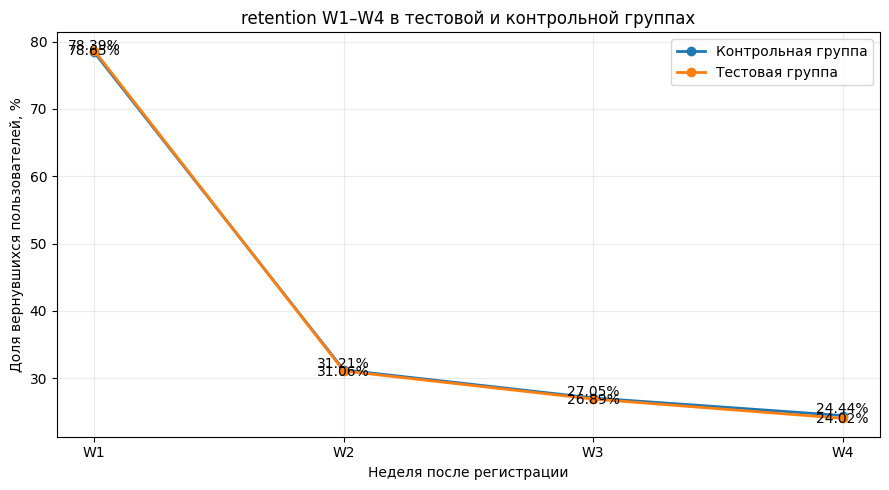

In [22]:

retention_plot = retention_results.pivot(index="week_number", columns="group_name", values="retention_pct")
plt.figure(figsize=(9, 5))
plt.plot(
    retention_plot.index,
    retention_plot["control"],
    marker="o",
    linewidth=2,
    label="Контрольная группа"
)

plt.plot(
    retention_plot.index,
    retention_plot["test"],
    marker="o",
    linewidth=2,
    label="Тестовая группа"
)

for week in retention_plot.index:
    plt.text(
        week,
        retention_plot.loc[week, "control"] + 0.3,
        f'{retention_plot.loc[week, "control"]:.2f}%',
        ha="center"
    )

    plt.text(
        week,
        retention_plot.loc[week, "test"] - 0.7,
        f'{retention_plot.loc[week, "test"]:.2f}%',
        ha="center"
    )

plt.title("retention W1–W4 в тестовой и контрольной группах")
plt.xlabel("Неделя после регистрации")
plt.ylabel("Доля вернувшихся пользователей, %")
plt.xticks([1, 2, 3, 4], ["W1", "W2", "W3", "W4"])
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

retention снижается в обеих группах: чем позже возврат от даты регистрации, тем retention ниже. Значения тестовой и контрольной групп близки, при этом в тестовой группе retention немного ниже на каждой неделе.

Используем z-тест долей, потому что: retention - бинарная метрика,
размеры групп большие

In [23]:
# H0 - персональные рекомендации не изменили вероятность возвращения
# H1 - персональные рекомендации повлияли на возвращение пользователей
from statsmodels.stats.multitest import multipletests
alpha = 0.05
retention_test_results = []
for week in [1, 2, 3, 4]:
    week_data = user_weeks[
        user_weeks["week_number"] == week]
    week_summary = (
        week_data
        .groupby("group_name")["retained"]
        .agg(
            retained_users="sum",
            users_count="count"
        )
        .reindex(["control", "test"])
    )

    control_retained = week_summary.loc[
        "control",
        "retained_users"
    ]

    control_users = week_summary.loc[
        "control",
        "users_count"
    ]

    test_retained = week_summary.loc[
        "test",
        "retained_users"
    ]

    test_users = week_summary.loc[
        "test",
        "users_count"
    ]

    control_retention = (control_retained / control_users)
    test_retention = (test_retained / test_users)
    absolute_effect_pp = (test_retention - control_retention) * 100
    relative_effect_pct = ((test_retention - control_retention) / control_retention * 100)
    z_stat, p_value = proportions_ztest(
        count=np.array([
            test_retained,
            control_retained
        ]),
        nobs=np.array([
            test_users,
            control_users
        ]),
        alternative="two-sided"
    )
    retention_test_results.append({
        "week": f"W{week}",
        "control_retention_pct": control_retention * 100,
        "test_retention_pct": test_retention * 100,
        "absolute_effect_pp": absolute_effect_pp,
        "relative_effect_pct": relative_effect_pct,
        "z_statistic": z_stat,
        "p_value": p_value
    })

retention_test_results = pd.DataFrame(retention_test_results)
retention_test_results

,week,control_retention_pct,test_retention_pct,absolute_effect_pp,relative_effect_pct,z_statistic,p_value
0,W1,78.391881,78.652215,0.260334,0.332092,0.506559,0.612464
1,W2,31.209992,31.055608,-0.154384,-0.494663,-0.266429,0.789908
2,W3,27.049180,26.892868,-0.156312,-0.577881,-0.281443,0.778371
3,W4,24.441842,24.018222,-0.423621,-1.733177,-0.790029,0.429511


на всех четырёх неделях p-value > 0,05, поэтому нет оснований отвергать нулевую гипотезу о равенстве долей вернувшихся пользователей. Статистически значимых различий между тестовой и контрольной группами не выявилось ни на одной неделе.

In [24]:
retention_table = retention_test_results.copy()

retention_table["test_name"] = "z-тест пропорций"

retention_table["significant"] = (retention_table["p_value"] < 0.05)

retention_summary_for_display = retention_table[
    [
        "week",
        "test_name",
        "control_retention_pct",
        "test_retention_pct",
        "absolute_effect_pp",
        "relative_effect_pct",
        "z_statistic",
        "p_value",
        "significant"
    ]
]


display(
    retention_summary_for_display.style.format({
        "control_retention_pct": "{:.2f}%",
        "test_retention_pct": "{:.2f}%",
        "absolute_effect_pp": "{:+.2f} п.п.",
        "relative_effect_pct": "{:+.2f}%",
        "z_statistic": "{:.4f}",
        "p_value": "{:.4f}"
    })
)

,week,test_name,control_retention_pct,test_retention_pct,absolute_effect_pp,relative_effect_pct,z_statistic,p_value,significant
0,W1,z-тест пропорций,78.39%,78.65%,+0.26 п.п.,+0.33%,0.5066,0.6125,False
1,W2,z-тест пропорций,31.21%,31.06%,-0.15 п.п.,-0.49%,-0.2664,0.7899,False
2,W3,z-тест пропорций,27.05%,26.89%,-0.16 п.п.,-0.58%,-0.2814,0.7784,False
3,W4,z-тест пропорций,24.44%,24.02%,-0.42 п.п.,-1.73%,-0.7900,0.4295,False


в данном случае нужна поправка на множественные сравнения, потому что мы проверяем одну продуктовую гипотезу сразу на четырёх неделях и проводим четыре теста.
При выполнении нескольких тестов с уровнем значимости α=0,05 увеличивается риск ошибки первого рода - обнаружить статистически значимое различие там, где реального эффекта нет. Для контроля этого риска будем использовать поправку Бонферрони

In [25]:
alpha = 0.05
tests_count = 4
bonferroni_alpha = alpha / tests_count

retention_table["significant_after_bonferroni"] = (retention_table["p_value"] < bonferroni_alpha)
print("Скорректированный уровень значимости:", bonferroni_alpha)

display(
    retention_table[
        [
            "week",
            "p_value",
            "significant_after_bonferroni"
        ]
    ].style.format({
        "p_value": "{:.4f}"
    })
)

Скорректированный уровень значимости: 0.0125


,week,p_value,significant_after_bonferroni
0,W1,0.6125,False
1,W2,0.7899,False
2,W3,0.7784,False
3,W4,0.4295,False


после применения поправки Бонферрони уровень значимости снизился с 0,05 до 0,0125. Все p-value превышают скорректированный уровень значимости, поэтому статистически значимых различий между тестовой и контрольной группами не обнаружено ни на одной неделе. Поправка не изменила первоначальный вывод.

retention постепенно снижается в обеих группах: с78% до 24% в контрольной и с 78% до 24% в тестовой группе. На первой неделе retention тестовой группы выше на 0,26 процентных пунктов, а на W2–W4 ниже на 0,15–0,42 п.п..Статистически значимого влияния персональных рекомендаций на возвращаемость пользователей не обнаружено. После применения поправки Бонферрони вывод не изменился.

Таким образом, персональные рекомендации шаблонов не оказали подтверждённого влияния на возвращаемость пользователей в течение первых четырёх недель после регистрации.Небольшая разница между группами недостаточна, чтобы сделать вывод о реальном эффекте возвращаемости пользователей. В результате вторая часть продуктовой гипотезы о росте возвращаемости пользователей не подтвердилась.

**ЗАДАНИЕ №4**

In [26]:
templates["event_dttm"] = pd.to_datetime(
    templates["event_dttm"],
    format="mixed"
)
experiment_start = pd.Timestamp("2026-04-01")
experiment_end = pd.Timestamp("2026-05-01")
# отбираем события за первый месяц эксперимента
templates_experiment = templates[
    (templates["event_dttm"] >= experiment_start)
    & (templates["event_dttm"] < experiment_end)
].copy()

print("Количество применений шаблонов за период:")
print(len(templates_experiment))

print("\nКоличество всех пользователей, применявших шаблоны:")
print(templates_experiment["user_id"].nunique())

templates_cnt = (
    templates_experiment
    .groupby("user_id", as_index=False)
    .agg(templates_per_user=("event_id", "nunique"))
)

templates_cnt.head()

templates_per_user_df = df[
    [
        "user_id",
        "group_name"
    ]
].merge(
    templates_cnt,
    on="user_id",
    how="left",
    validate="one_to_one"
)

templates_per_user_df["templates_per_user"] = (
    templates_per_user_df["templates_per_user"]
    .fillna(0)
    .astype(int)
)

templates_per_user_df.head()

Количество применений шаблонов за период:
3800

Количество всех пользователей, применявших шаблоны:
1823


,user_id,group_name,templates_per_user
0,2fc14f889d52a89,control,0
1,c118a6226618b3f,control,0
2,3ef46bf37f0e3be,test,0
3,d7ab835a0f1329a,control,0
4,29f7e4f0ce4bc97,control,0


описательная статистика

In [27]:
print("Количество пользователей - участников теста за период теста:")
print(len(templates_per_user_df))

print("\nПропуски:")
print(templates_per_user_df["templates_per_user"].isna().sum())

print("\nМинимальное значение:")
print(templates_per_user_df["templates_per_user"].min())

print("\nКоличество пользователей - участников теста без шаблонов за период теста:")
print((templates_per_user_df["templates_per_user"] == 0).sum())

templates_stats = (
    templates_per_user_df
    .groupby("group_name")["templates_per_user"]
    .agg(
        users_count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        skew="skew"
    )
    .round(4)
)

templates_stats

Количество пользователей - участников теста за период теста:
25542

Пропуски:
0

Минимальное значение:
0

Количество пользователей - участников теста без шаблонов за период теста:
24533


,users_count,mean,median,std,min,max,skew
group_name,,,,,,,
control,12810,0.0799,0.0,0.5996,0,23,16.4301
test,12732,0.0747,0.0,0.5385,0,19,15.3624


что мы видим: большинство пользователей в первый месяц эксперимента не применяли шаблоны. Распределение templates_per_user содержит большое количество нулей и небольшую группу пользователей с высокой активностью. В тестовой группе среднее значение немного ниже - 0,0747 против 0,0799.

распределение метрики

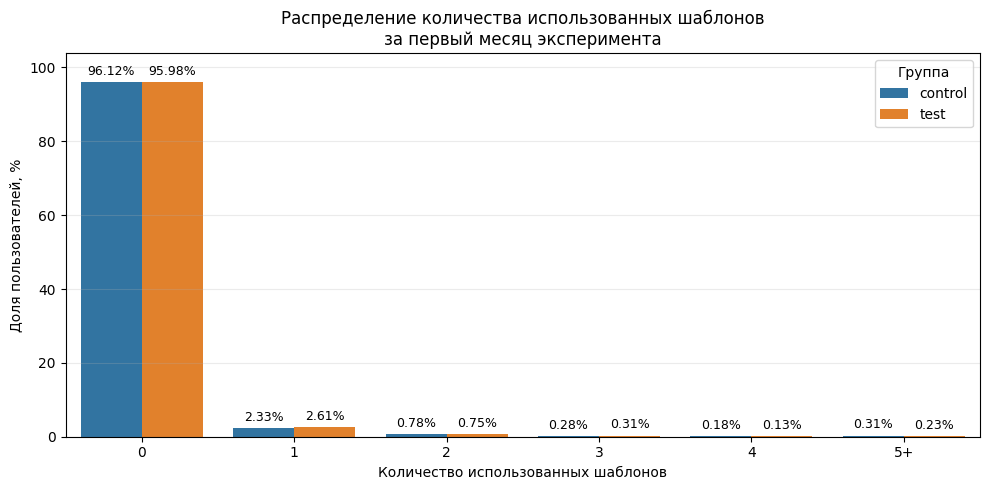

In [28]:
 templates_per_user_df["templates_category"] = np.where(
    templates_per_user_df["templates_per_user"] >= 5,
    "5+",
    templates_per_user_df["templates_per_user"].astype(str)
)

category_order = ["0", "1", "2", "3", "4", "5+"]
templates_distribution = (
    templates_per_user_df
    .groupby(
        [
            "group_name",
            "templates_category"
        ],
        observed=True
    )
    .size()
    .rename("users_count")
    .reset_index()
)

templates_distribution["users_share"] = (
    templates_distribution["users_count"]
    / templates_distribution.groupby("group_name")[
        "users_count"
    ].transform("sum")
    * 100
)
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=templates_distribution,
    x="templates_category",
    y="users_share",
    hue="group_name",
    order=category_order
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.2f}%"
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.title(
    "Распределение количества использованных шаблонов\n"
    "за первый месяц эксперимента"
)
plt.xlabel("Количество использованных шаблонов")
plt.ylabel("Доля пользователей, %")
plt.legend(title="Группа")
plt.grid(axis="y", alpha=0.25)
plt.ylim(0, templates_distribution["users_share"].max() * 1.08)
plt.tight_layout()
plt.show()

около 96% пользователей в обеих группах не использовали ни одного шаблона.
один шаблон использовали 2,33% пользователей контроля и 2,61% теста.
пользователей с двумя и более шаблонами очень мало.
распределения групп схожи.
у контроля немного больше пользователей в категории 5+, что объясняет более высокое среднее и максимум.

In [29]:
used_template_share = (
    templates_per_user_df
    .assign(
        used_template=(
            templates_per_user_df["templates_per_user"] > 0
        )
    )
    .groupby("group_name")["used_template"]
    .mean()
    .mul(100)
    .round(2)
)

print("Доля пользователей, использовавших хотя бы один шаблон:")
print(used_template_share)

Доля пользователей, использовавших хотя бы один шаблон:
group_name
control    3.88
test       4.02
Name: used_template, dtype: float64


распределение метрики сильно смещено вправо (так как группа пользователей без шаблона преобладает над остальными) и содержит большое количество нулевых значений: около 96% пользователей в обеих группах не применили ни одного шаблона. Медиана равна нулю, а среднее формируется небольшой группой активных пользователей. Распределения тестовой и контрольной групп схожи. В тестовой группе немного выше доля пользователей, применивших хотя бы один шаблон, однако в контрольной группе больше пользователей с высокой активностью.  

будем использовать t-тест Уэлча, так как:
метрика количественная,
тестовая и контрольная группы независимы,
сравниваем средние,
выборки большие - более 12 тысяч пользователей,
распределение исходной метрики скошено, но по ЦПТ распределение разницы средних стремится к нормальному,
диспрсии не равны, а Уэлч не требует равенства дисперсий

H0: среднее количество шаблонов, использованных за первый месяц эксперимента, одинаково в тестовой и контрольной группах. Персональные рекомендации не повлияли на среднее количество используемых шаблонов.
H1: среднее количество шаблонов, использованных за первый месяц эксперимента, различается между тестовой и контрольной группами. Персональные рекомендации повлияли на среднее количество используемых шаблонов.

In [30]:
from scipy.stats import ttest_ind
control = templates_per_user_df.loc[
    templates_per_user_df["group_name"] == "control",
    "templates_per_user"
]

test = templates_per_user_df.loc[
    templates_per_user_df["group_name"] == "test",
    "templates_per_user"
]

t_stat, p_value = ttest_ind(
    test,
    control,
    equal_var=False,
    alternative="two-sided"
)

print(f"Среднее control: {control.mean():.4f}")
print(f"Среднее test: {test.mean():.4f}")
print(f"T-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Среднее control: 0.0799
Среднее test: 0.0747
T-статистика: -0.7245
p-value: 0.4688


p-value = 0,4688 > 0,05, поэтому нет оснований отвергать нулевую гипотезу. Статистически значимых различий в среднем количестве использованных шаблонов между тестовой и контрольной группами не обнаружено.

In [31]:
control_mean = control.mean()
test_mean = test.mean()

absolute_effect = (test_mean - control_mean)
relative_effect_pct = (absolute_effect / control_mean * 100)
templates_test_summary = pd.DataFrame([
    {
        "metric": "templates_per_user",
        "test_name": "t-тест Уэлча",
        "control_mean": control_mean,
        "test_mean": test_mean,
        "absolute_effect": absolute_effect,
        "relative_effect_pct": relative_effect_pct,
        "statistic": t_stat,
        "p_value": p_value,
        "significant": p_value < 0.05
    }
])
display(
    templates_test_summary.style.format({
        "control_mean": "{:.4f}",
        "test_mean": "{:.4f}",
        "absolute_effect": "{:+.4f}",
        "relative_effect_pct": "{:+.2f}%",
        "statistic": "{:.4f}",
        "p_value": "{:.4f}"
    })
)

,metric,test_name,control_mean,test_mean,absolute_effect,relative_effect_pct,statistic,p_value,significant
0,templates_per_user,t-тест Уэлча,0.0799,0.0747,-0.0052,-6.47%,-0.7245,0.4688,False


при уровне значимости 5% и мощности 80% эксперимент способен обнаружить изменение среднего templates_per_user примерно на 0,02 шаблона на пользователя, или на 25% относительно контрольной группы. Наблюдаемый эффект составил только −0,0052, или −6,47%, что значительно меньше MDE. Следовательно, эксперимент не обладает достаточной чувствительностью, чтобы надёжно обнаружить эффект такого размера.

Статистический вывод:
среднее количество использованных шаблонов за первый месяц составило 0,0799 на пользователя в контрольной группе и 0,0747 в тестовой. Абсолютная разница равна −0,0052 шаблона на пользователя, относительная — −6,47%. По результатам t-теста Уэлча различие статистически незначимо. Поэтому нет оснований отвергать нулевую гипотезу о равенстве средних.

Продуктовый вывод

Персональные рекомендации не привели к изменению количества шаблонов, использованных пользователями за первый месяц эксперимента. Хотя среднее значение в тестовой группе немного ниже, полученную разницу нельзя считать доказанным негативным эффектом.

При этом около 96% пользователей в обеих группах не использовали ни одного шаблона. Таким образом, персональные рекомендации в текущем виде не привели к повышению вовлеченности пользователей в работу с шаблонами. Возможно, лучше сконцентрировать на повышение метрики вовлеченности при первом применении, например, показывать для каких целей предназначен тот или иной шаблон.Также, в датасете очень много пропусков относительно сферы деятельности, поэтому персональные рекомендации могут быть нерелевантными.

какие еще а/б тесты?
1. предназначение шаблонов: Контроль - только название и изображение шаблона. тест - описание для чего шаблон, в каких задачах полезнен
2. Контроль: текущий интерфейс, где пустая доска и шаблоны находятся в одном ряду.
Тест: пустая доска и шаблоны разделены на два визуально и смыслово разных сценария — Начать с нуля и Начать с шаблона.

ЗАДАНИЕ №5

In [32]:
alpha = 0.05
power = 0.80
n_control = len(control)
n_test = len(test)
control_mean = control.mean()
control_variance = control.var(ddof=1)
test_variance = test.var(ddof=1)

z_alpha = norm.ppf(1 - alpha / 2)
z_power = norm.ppf(power)

standard_error = np.sqrt(control_variance / n_control + test_variance / n_test)
absolute_mde = (z_alpha + z_power) * standard_error
relative_mde_pct = (absolute_mde / control_mean * 100)
observed_effect = (test.mean() - control.mean())
observed_effect_pct = (observed_effect / control.mean() * 100)

print(f"Размер control: {n_control}")
print(f"Размер test: {n_test}")
print(f"\nСреднее control: {control_mean:.4f}")
print(f"\nАбсолютный MDE: {absolute_mde:.4f}")
print(f"Относительный MDE: {relative_mde_pct:.2f}%")
print(f"\nНаблюдаемый эффект: {observed_effect:.4f}")
print(
    f"Наблюдаемый относительный эффект: "
    f"{observed_effect_pct:.2f}%"
)

Размер control: 12810
Размер test: 12732

Среднее control: 0.0799

Абсолютный MDE: 0.0200
Относительный MDE: 25.01%

Наблюдаемый эффект: -0.0052
Наблюдаемый относительный эффект: -6.47%


при текущем размере выборки тест способен обнаружить изменение метрики templates_per_user не меньше чем на 0,02 шаблона на пользователя.

Наблюдаемый эффект составил −0,0052, или −6,47%. По модулю он значительно меньше MDE: 0,0052 < 0,02. Следовательно, чувствительности эксперимента недостаточно, чтобы надёжно обнаружить изменение такого размера.

Отсутствие статистической значимости означает, что при текущем объёме выборки наблюдаемое снижение на 6,47% невозможно невозможно назвать неслучайным. Для обнаружения такого небольшого эффекта требуется увеличить выборку либо снизить разброс метрики.То есть, одного месяца недостаточно, чтобы надёжно обнаружить изменение такого размера.

In [33]:
import math
alpha = 0.05
power = 0.80
control_mean = 0.080
control_std = 0.600
test_std = 0.539
target_uplift = 0.05
#эффект, который хотим обнаружить
target_effect = control_mean * target_uplift
pooled_std = np.sqrt((control_std**2 + test_std**2) / 2)


z_alpha = norm.ppf(1 - alpha / 2)
z_power = norm.ppf(power)

n_per_group = math.ceil(
    2
    * (z_alpha + z_power)**2
    * pooled_std**2
    / target_effect**2
)

total_sample = n_per_group * 2

print(f"Базовое значение метрики: {control_mean:.3f}")
print(f"Ожидаемый относительный uplift: {target_uplift:.0%}")
print(f"Ожидаемый абсолютный эффект: {target_effect:.4f}")
print(f"Необходимая выборка на группу: {n_per_group:,} тыс.")
print(f"Общая необходимая выборка: {total_sample:,} тыс.")

Базовое значение метрики: 0.080
Ожидаемый относительный uplift: 5%
Ожидаемый абсолютный эффект: 0.0040
Необходимая выборка на группу: 319,117 тыс.
Общая необходимая выборка: 638,234 тыс.


размер текущей выборки составляет около 12 700 пользователей в обеих группах, что примерно в 25 раз меньше необходимой. Следовательно, одного месяца эксперимента недостаточно для надёжного обнаружения роста метрики на 5%.

 Главная проблема метрики templates_per_user - её высокая разреженность: около 96% пользователей за первый месяц эксперимента не применили ни одного шаблона. При этом небольшое количество активных пользователей применяет шаблоны много раз, из-за чего распределение имеет длинный правый хвост и высокую дисперсию. Это снижает чувствительность статистического теста.

Для повышения чувствительности эксперимента можно использовать следующие подходы.

1. Выбрать метрику, соответствующую механике воздействия

В качестве дополнительной метрики можно использовать долю пользователей, применивших хотя бы один шаблон:

used_template = templates_per_user > 0

Эта метрика показывает, увеличили ли персональные рекомендации вероятность первого применения шаблона. Для её сравнения между группами можно использовать z-тест долей.

Однако бинаризация приводит к потере информации о повторных применениях. Поэтому долю пользователей, применивших шаблон, лучше смотреть вместе с templates_per_user.

Также можно отдельно анализировать интенсивность использования среди пользователей, применивших хотя бы один шаблон. Такая метрика будет условной и должна рассматриваться как дополнительная, поскольку состав активных пользователей может зависеть от экспериментального воздействия.

2. Применить CUPED

Можно использовать количество применённых шаблонов или другую активность пользователя (сколько раз пользователь повторно применял шаблоны, как часто возвращался к работе с шаблонами) до начала эксперимента как доп показатель. Если активность до и во время теста коррелирует, CUPED снизит дисперсию метрики и позволит обнаруживать меньшие эффекты на той же выборке.

3. Использовать стратификацию

При планировании следующего эксперимента пользователей можно распределять по группам внутри заранее определённых страт, например по:

активности до начала эксперимента;
сфере деятельности;
факту использования шаблонов до эксперимента;
типу устройства.

Стратификация может уменьшить случайные различия между группами и снизить дисперсию оценки эффекта. При этом для формирования страт следует выбирать признаки, которые связаны с целевой метрикой. Если возраст или сфера деятельности слабо связаны с использованием шаблонов, стратификация по ним не даст заметного выигрыша.

4. Ограничить влияние выбросов

Небольшое число пользователей применяет шаблоны значительно чаще остальных, из-за чего дисперсия метрики увеличивается. Для снижения влияния таких наблюдений можно заранее определить верхний порог и применить винзоризацию, например ограничить значения на уровне 99-го процентиля.

Порог необходимо устанавливать до проверки статистической значимости и одинаково применять к тестовой и контрольной группам. После преобразования следует отдельно показать, насколько изменились дисперсия, оценка эффекта и p-value.

CUPED

In [34]:
preperiod_start = pd.Timestamp('2026-03-01')
experiment_start = pd.Timestamp('2026-04-01')
experiment_end = pd.Timestamp('2026-05-01')

templates_preperiod = templates[
    (templates['event_dttm'] >= preperiod_start)
    & (templates['event_dttm'] < experiment_start)
]

cuped_df = df[
    ['user_id', 'group_name']
].copy()

preperiod_metric = (
    templates_preperiod
    .groupby("user_id")["event_id"]
    .nunique()
    .rename("templates_preperiod")
)

templates_experiment = templates[
    (templates['event_dttm'] >= experiment_start)
    & (templates['event_dttm'] < experiment_end)
]

experiment_metric = (
    templates_experiment
    .groupby('user_id')['event_dttm']
    .nunique()
    .rename('templates_experiment')
)
cuped_df = cuped_df.merge(
    preperiod_metric,
    on="user_id",
    how="left"
)

cuped_df = cuped_df.merge(
    experiment_metric,
    on="user_id",
    how="left"
)

cuped_df[
    ["templates_preperiod", "templates_experiment"]
] = cuped_df[
    ["templates_preperiod", "templates_experiment"]
].fillna(0)

In [36]:
x = cuped_df["templates_preperiod"]
y = cuped_df["templates_experiment"]

theta = np.cov(y, x, ddof=1)[0, 1] / x.var(ddof=1)

cuped_df["templates_experiment_cuped"] = (
    y - theta * (x - x.mean())
)

correlation = x.corr(y)

raw_variance = y.var(ddof=1)
cuped_variance = (
    cuped_df["templates_experiment_cuped"].var(ddof=1)
)

variance_reduction_pct = (
    1 - cuped_variance / raw_variance
) * 100

print(f"Корреляция X и Y: {correlation:.4f}")
print(f"Theta: {theta:.4f}")
print(f"Дисперсия исходной метрики: {raw_variance:.6f}")
print(f"Дисперсия после CUPED: {cuped_variance:.6f}")
print(
    f"Снижение дисперсии: "
    f"{variance_reduction_pct:.4f}%"
)

Корреляция X и Y: 0.0134
Theta: 0.0137
Дисперсия исходной метрики: 0.324867
Дисперсия после CUPED: 0.324809
Снижение дисперсии: 0.0180%


In [40]:
control_cuped = cuped_df.loc[
    cuped_df["group_name"] == "control",
    "templates_experiment_cuped"
]

test_cuped = cuped_df.loc[
    cuped_df["group_name"] == "test",
    "templates_experiment_cuped"
]

t_stat_cuped, p_value_cuped = ttest_ind(
    test_cuped,
    control_cuped,
    equal_var=False,
    alternative="two-sided"
)

cuped_results = pd.DataFrame([
    {
        "analysis": "Исходная метрика",
        "control_mean": control.mean(),
        "test_mean": test.mean(),
        "absolute_effect": test.mean() - control.mean(),
        "p_value": p_value,
        "variance": raw_variance,
        "significant": p_value < 0.05
    },
    {
        "analysis": "После CUPED",
        "control_mean": control_cuped.mean(),
        "test_mean": test_cuped.mean(),
        "absolute_effect": (
            test_cuped.mean() - control_cuped.mean()
        ),
        "p_value": p_value_cuped,
        "variance": cuped_variance,
        "significant": p_value < 0.05
    }
])

display(
    cuped_results.style.format({
        "control_mean": "{:.6f}",
        "test_mean": "{:.6f}",
        "absolute_effect": "{:+.6f}",
        "p_value": "{:.4f}",
        "variance": "{:.6f}"

    })
)

,analysis,control_mean,test_mean,absolute_effect,p_value,variance,significant
0,Исходная метрика,0.079859,0.074694,-0.005166,0.4688,0.324867,False
1,После CUPED,0.079862,0.074691,-0.005171,0.4683,0.324809,False


В качестве ковариаты использовано количество шаблонов, применённых пользователем за месяц до начала эксперимента. Корреляция предэкспериментальной и экспериментальной метрик составила только 0,0134. Поэтому CUPED снизил дисперсию с 0,324867 до 0,324809, то есть лишь на 0,018%.

После CUPED абсолютный эффект практически не изменился и составил около −0,00517 шаблона на пользователя. P-value изменился с 0,4688 до 0,4683 и остался значительно выше уровня значимости 0,05. Таким образом, CUPED применён корректно, но выбранная предэкспериментальная метрика почти не связана с целевой метрикой и не дала существенного выигрыша в чувствительности. Вывод об отсутствии статистически значимого эффекта персональных рекомендаций не изменился.